In [ ]:
#import libraries
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# define the path to the dataset
DATA_PATH = "E:\project_phase1\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

In [ ]:
# use filtered dataset from the previous notebook
dataset = pd.read_csv("processed_metadata.csv")

In [ ]:
# function to load lead II signal from a given record
def load_leadII(filename):

    record_path = os.path.join(DATA_PATH, filename)

    signal, _ = wfdb.rdsamp(record_path)

    leadII = signal[:, 1]

    return leadII

In [5]:
# load all ECG signals

X = []
y = []

for _, row in dataset.iterrows():

    signal = load_leadII(row["filename_lr"])

    X.append(signal)

    y.append(row["label"])

X = np.array(X)
y = np.array(y)

In [ ]:
# verify shapes of the loaded data
print("ECG Signals Shape :", X.shape)
print("Labels Shape      :", y.shape)

ECG Signals Shape : (14982, 1000)
Labels Shape      : (14982,)


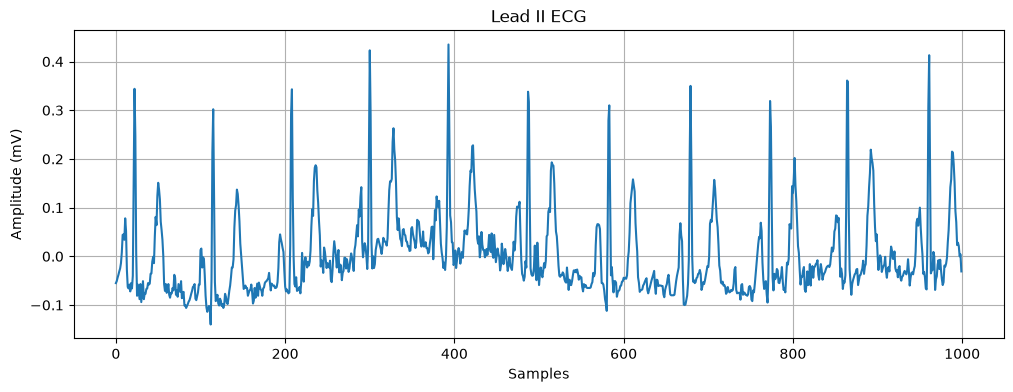

In [ ]:
#Plot One ECG
plt.figure(figsize=(12,4))

plt.plot(X[0])

plt.title("Lead II ECG")

plt.xlabel("Samples")

plt.ylabel("Amplitude (mV)")

plt.grid(True)

plt.show()

In [8]:
# Normalize the ECG signals using StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [9]:
print(np.mean(X))
print(np.std(X))

-9.470109029273582e-18
0.9999999999999999


In [ ]:
# Reshape for 1D CNN
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

In [11]:
print(X.shape)

(14982, 1000, 1)


In [12]:
#train-test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [13]:
#validation split
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.20,random_state=42,stratify=y_train)

In [14]:
# print dataset shapes
print("Training Set  :", X_train.shape)

print("Validation Set:", X_val.shape)

print("Testing Set   :", X_test.shape)

Training Set  : (9588, 1000, 1)
Validation Set: (2397, 1000, 1)
Testing Set   : (2997, 1000, 1)


In [15]:
#Compute class weights to handle class imbalance
weights = compute_class_weight(class_weight="balanced",classes=np.unique(y_train),y=y_train)

class_weights = {
    0: weights[0],
    1: weights[1]
    }

print(class_weights)

{0: np.float64(0.7874507227332457), 1: np.float64(1.3697142857142857)}


In [16]:
# Verify label distribution
print("Training Labels")

print(pd.Series(y_train).value_counts())

print()

print("Validation Labels")

print(pd.Series(y_val).value_counts())

print()

print("Testing Labels")

print(pd.Series(y_test).value_counts())

Training Labels
0    6088
1    3500
Name: count, dtype: int64

Validation Labels
0    1522
1     875
Name: count, dtype: int64

Testing Labels
0    1903
1    1094
Name: count, dtype: int64


In [17]:
np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)
np.save("X_test.npy", X_test)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)